# NeuroWorkflow: Ring Network — 3 Point Neurons

Three `iaf_psc_alpha` neurons connected in a ring topology:
**popA → popB → popC → popA**

Demonstrates the **fan-in** `NW_Connectivity` node: all three populations
connect to a single connectivity node that defines the full connection matrix.

```
PopA ─┐
PopB ─┼─→ NW_Connectivity (ring matrix) → NW_SimConfig → NW_Analysis
PopC ─┘
```

Each neuron is driven by a constant bias current (`I_e`) so it fires
spontaneously. The ring connections modulate timing and phase relationships.

In [1]:
#!pip install "numpy<2.0"

In [2]:
import os
import sys

sys.path.insert(0, os.path.abspath('../../../..'))  # neuro-workflow/src

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.sandbox.NW_Population   import NW_Population
from neuroworkflow.nodes.sandbox.NW_Connectivity import NW_Connectivity
from neuroworkflow.nodes.sandbox.NW_SimConfig    import NW_SimConfig
from neuroworkflow.nodes.sandbox.NW_Analysis     import NW_Analysis

## 1. Instantiate nodes

In [3]:
popA = NW_Population("PopA")
popB = NW_Population("PopB")
popC = NW_Population("PopC")

conn = NW_Connectivity("Connectivity")
cfg  = NW_SimConfig("SimConfig")
ana  = NW_Analysis("Analysis")

print(conn.get_info())

{'name': 'Connectivity', 'type': 'nw_connectivity', 'description': 'Receives all population builders via a fan-in port and wires directed projections according to the connections list. Each connection spec can override the node-level synapse defaults (model, weight, delay, etc.), allowing mixed synapse types in a single connectivity node.', 'parameters': {'connections': [{'source': 'popA', 'target': 'popB'}], 'connection_rule': 1, 'model_template': 'static_synapse', 'dynamics_params': 'conn_syn.json', 'dynamics_params_dict': {}, 'delay': 2.0, 'syn_weight': 5.0, 'allow_autapses': False, 'allow_multapses': True}, 'optimizable_parameters': {}, 'input_ports': {'populations': {'type': 'object', 'description': 'Fan-in port: connect any number of NW_Population outputs here. Each carries {builder, pop_name, network_dir}. Populations are identified by their pop_name parameter.', 'optional': False}}, 'output_ports': {'network': {'type': 'object', 'description': 'Dict keyed by pop_name containing

## 2. Configure nodes

Each neuron has a bias current `I_e = 400 pA` (just above rheobase for
`iaf_psc_alpha` with default parameters) so it fires spontaneously at ~5 Hz.
The ring connections couple the neurons and shift their relative timing.

In [4]:
neuron_params = dict(
    model_type     = "point_neuron",
    model_template = "nest:iaf_psc_alpha",
    ei_type        = "exc",
    location       = "VISp",
    layer          = "L4",
    N              = 1,
    nest_params = {
        "C_m":     250.0,   # pF
        "tau_m":   10.0,    # ms
        "t_ref":   2.0,     # ms
        "V_th":    -55.0,   # mV
        "V_reset": -70.0,   # mV
        "E_L":     -70.0,   # mV
        "I_e":     400.0,   # pA  — bias current, drives spontaneous firing
    },
)

popA.configure(pop_name="popA", **neuron_params)
popB.configure(pop_name="popB", **neuron_params)
popC.configure(pop_name="popC", **neuron_params)

# Ring connectivity matrix: A→B→C→A
# iaf_psc_alpha is current-based → weights in pA.
# Demonstrates mixed synapse models per connection:
#   popA→popB : static_synapse  (fixed weight, no plasticity)
#   popB→popC : stdp_synapse    (weight adapts to spike timing)
#   popC→popA : static_synapse  (fixed weight, shorter delay)
conn.configure(
    connection_rule      = 1,
    model_template       = "static_synapse",
    dynamics_params      = "static_syn.json",
    dynamics_params_dict = {},             # empty — static_synapse needs no extra params
    delay                = 2.0,            # ms
    syn_weight           = 50.0,           # pA

    connections = [
        # A→B: static synapse, inherits node-level defaults
        {
            "source": "popA",
            "target": "popB",
        },
        # B→C: STDP synapse — weight evolves with pre/post spike timing
        {
            "source":               "popB",
            "target":               "popC",
            "model_template":       "stdp_synapse",
            "dynamics_params":      "stdp_syn.json",
            "dynamics_params_dict": {
                "tau_plus": 20.0,   # ms  — pre-before-post time constant (LTP window)
                "lambda":   0.01,   # learning rate
                "alpha":    1.0,    # ratio of LTD to LTP amplitude
                "mu_plus":  1.0,    # weight dependence exponent (LTP)
                "mu_minus": 1.0,    # weight dependence exponent (LTD)
                "Wmax":     500.0,  # pA  — maximum allowed weight
            },
        },
        # C→A: static synapse, faster feedback
        {
            "source": "popC",
            "target": "popA",
            "delay":  1.0,                 # ms  — shorter delay for this connection
        },
    ],
)

cfg.configure(
    simulator   = "pointnet",
    config_file = "config_ring.json",
    tstop_ms    = 3000.0,
    dt_ms       = 0.1,
    reports = {
        "v_report": {
            "variable_name": "V_m",
            "cells":         "all",
            "module":        "membrane_report",
            "sections":      "soma",
        }
    },
)

ana.configure(
    plot_raster  = True,
    plot_traces  = True,
    report_name  = "v_report",
    save_figures = True,
)

## 3. Build and run the workflow

All three populations connect to the **same** `Connectivity` fan-in port.
NeuroWorkflow collects them into a list; `NW_Connectivity` converts to a
`pop_name` lookup and applies the connection matrix.

Executing node: PopC
Executing node: PopB
Executing node: PopA
Executing node: Connectivity
Executing node: SimConfig

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-06-17 14:20:41,723 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:20:41,739 [INFO] Batch processing nodes for popC/0.


INFO:NestIOUtils:Batch processing nodes for popC/0.


2026-06-17 14:20:41,748 [INFO] Batch processing nodes for popB/0.


...

2026-06-17 14:20:41,833 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:20:41,866 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


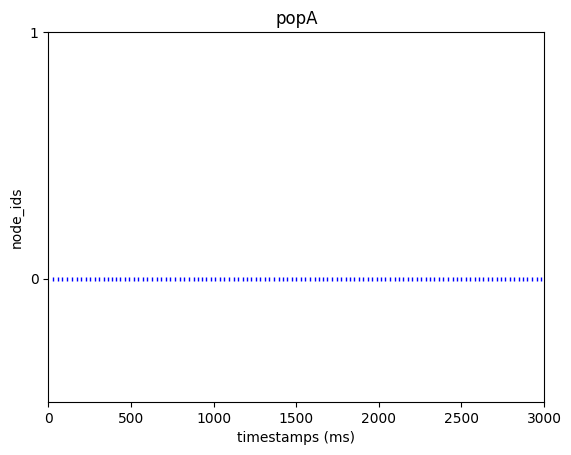

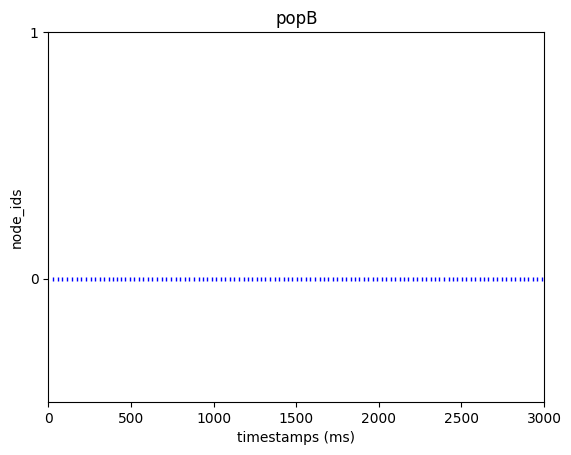

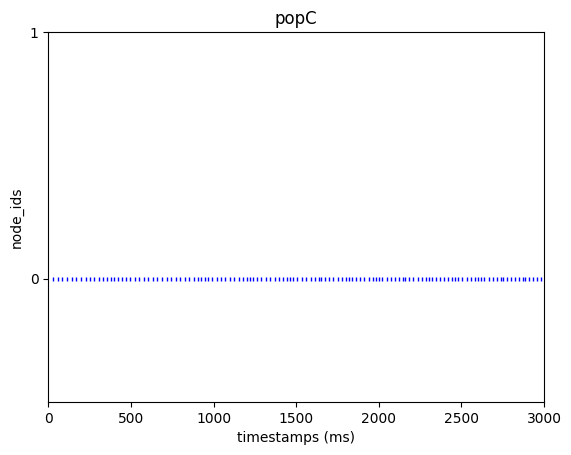

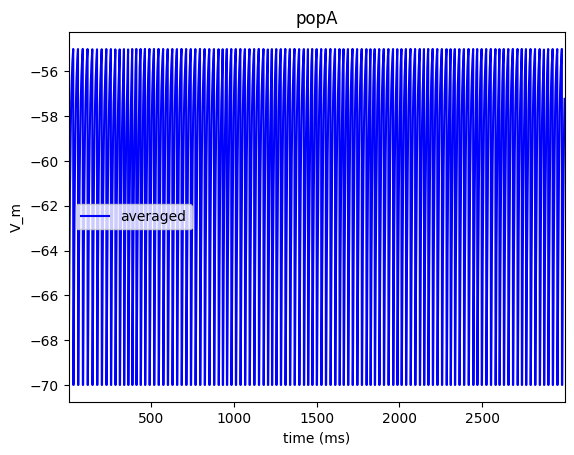

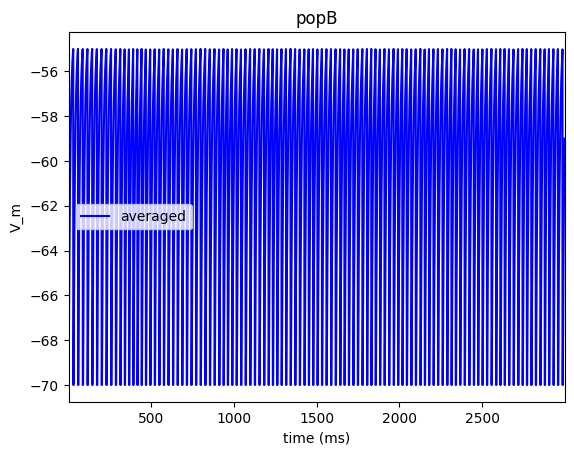

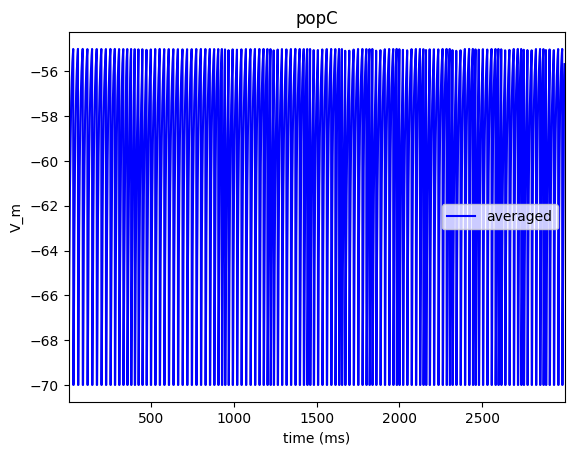

Workflow completed successfully


In [5]:
wf = WorkflowBuilder("NW_Ring_3Pop")

for node in [popA, popB, popC, conn, cfg, ana]:
    wf.add_node(node)

# Fan-in: all 3 populations → single Connectivity port
wf.connect("PopA", "population",  "Connectivity", "populations")
wf.connect("PopB", "population",  "Connectivity", "populations")
wf.connect("PopC", "population",  "Connectivity", "populations")

wf.connect("Connectivity", "network", "SimConfig", "populations")
wf.connect("SimConfig",    "results", "Analysis",  "results")

wf.context["results_path"] = "./results/ring"

workflow = wf.build()
ok = workflow.execute()
assert ok, "Workflow failed — check printed errors above"
print("Workflow completed successfully")

## 4. Validate outputs

In [6]:
print("Output validation:")
for node_name, node in workflow.nodes.items():
    for port_name, port in node._output_ports.items():
        status = "OK" if port.value is not None else "*** None — node may have failed ***"
        print(f"  {node_name}.{port_name}: {status}")

Output validation:
  PopA.population: OK
  PopB.population: OK
  PopC.population: OK
  Connectivity.network: OK
  SimConfig.results: OK
  Analysis.figures: OK


## 5. Re-run with stronger coupling

Increase `syn_weight` to see tighter phase-locking between neurons.
No need to rebuild the workflow — just reconfigure and re-execute.

Executing node: PopC
Executing node: PopB
Executing node: PopA
Executing node: Connectivity
Executing node: SimConfig
2026-06-17 14:20:42,962 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:20:42,968 [INFO] Batch processing nodes for popC/0.


INFO:NestIOUtils:Batch processing nodes for popC/0.


2026-06-17 14:20:42,974 [INFO] Batch processing nodes for popB/0.


...

2026-06-17 14:20:43,043 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:20:43,070 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


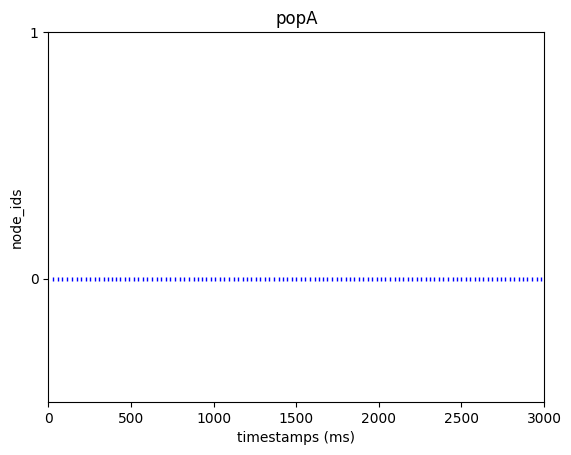

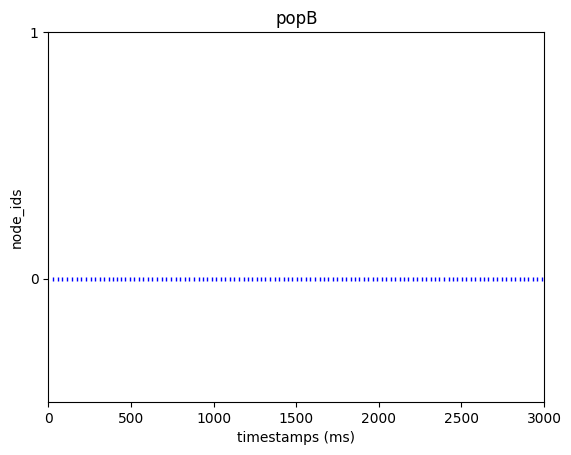

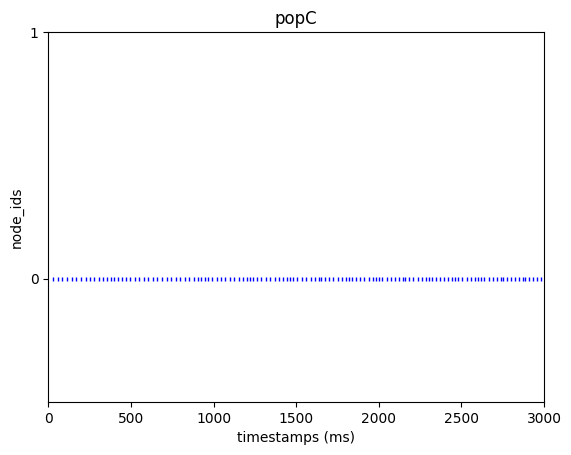

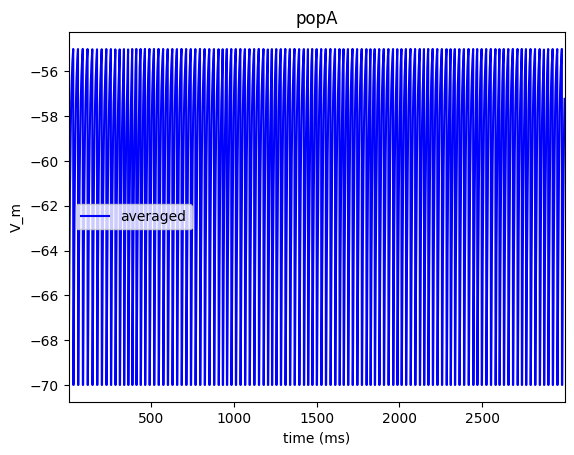

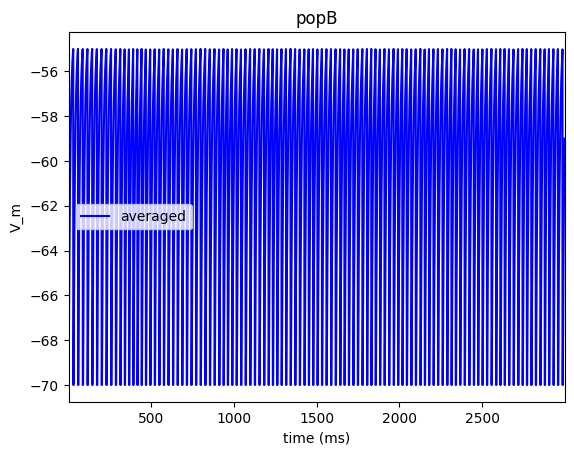

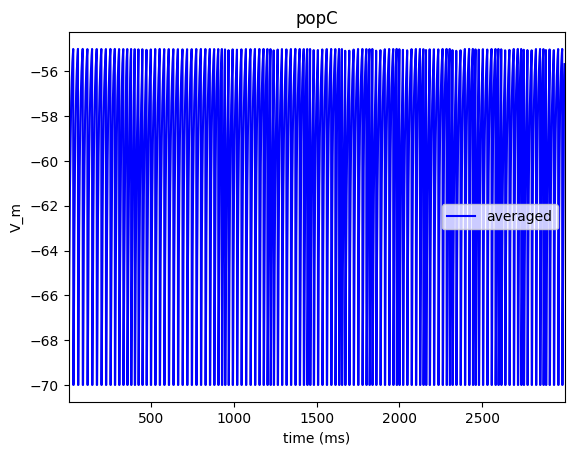

Re-run complete


In [7]:
conn.configure(syn_weight=50.0)
cfg.configure(config_file="config_ring_strong.json")

for node in workflow.nodes.values():
    node._context["results_path"] = "./results/ring_strong"

ok = workflow.execute()
assert ok, "Re-run failed"
print("Re-run complete")